In [125]:
import numpy as np
import matplotlib.pyplot as plt

### Q4
Write a simple accept-reject generator in python which can generate from an arbitary function of a random variable, f(X).

In [126]:
# x range
xrange = (-5,5)

# a
def func_a(x):
    return np.cos(x)**2

# b
def func_b(x):
    return np.sin(x) + np.cos(x) + 2

# c
def func_c(x):
    return ((np.sin(x) + np.cos(x))/(np.sinh(x) + np.cosh(x))) + 25

In [127]:
from scipy.optimize import brute

def f_neg(func):
    return lambda x: -func(x)

def find_ymax(func):
    x_opt = brute(f_neg(func), [xrange], finish=None)
    ymax = func(x_opt)
    print(f"y_max: {ymax:.2f}")
    return ymax

f_a_ymax = find_ymax(func_a)
f_b_ymax = find_ymax(func_b)
f_c_ymax = find_ymax(func_c)

y_max: 0.94
y_max: 3.41
y_max: 209.42


In [128]:
def gen_accept_reject(func, ymax, size):
    res = []
    while len(res)<size:
        a = np.random.uniform(*xrange)
        b = np.random.uniform(0,ymax)
        y = func(a)
        if y > ymax:
            print('Some issue: as y larger than ymax')
        if b <= y:
            res.append(a)
    return res

In [129]:
def plotter(func, ymax, size=5000):
    v = gen_accept_reject(func, ymax, size)
    x = np.linspace(*xrange, 200)
    y = func(x)
    y_scaled = y / np.trapezoid(y, x)

    plt.figure(figsize=(7,4))
    plt.hist(v, range=xrange, bins=50, density=True, alpha=0.5, label="Samples")
    plt.plot(x, y_scaled, 'r', label="Target pdf (scaled)")
    plt.title(f"Accept-Reject Sampling")
    plt.xlabel("x")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as

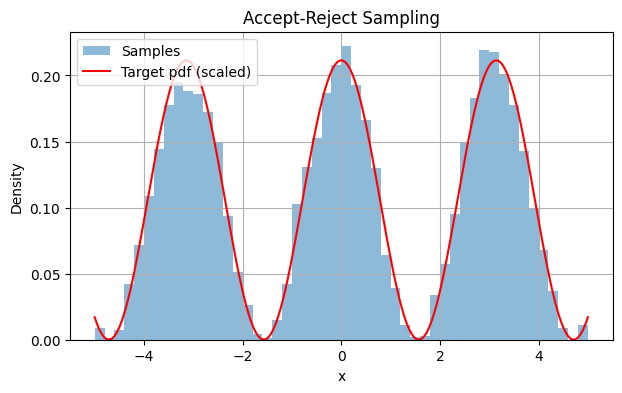

In [130]:
plotter(func_a, f_a_ymax)

Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax
Some issue: as y larger than ymax


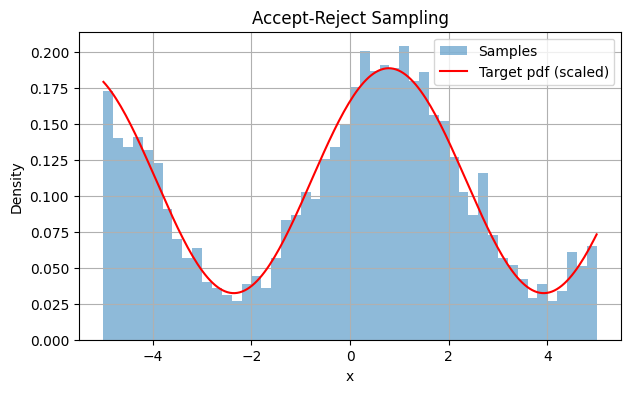

In [131]:
plotter(func_b, f_b_ymax)

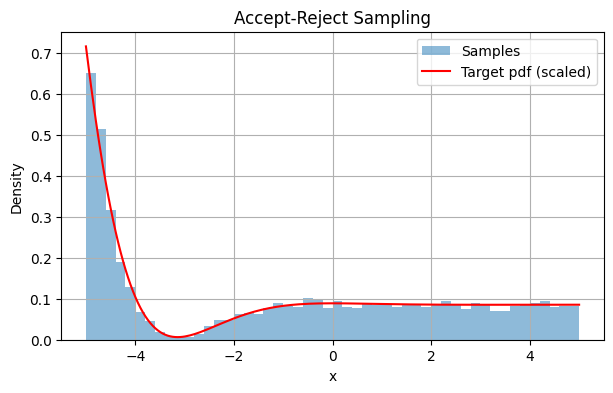

In [132]:
plotter(func_c, f_c_ymax)